# Tesis — Solución 1.3 (desacoplada) y Solución 1.2 (acoplada)

Notebook corregido. Cambios respecto a la versión anterior:

1. **Namespaces separados** (`_13` para el sistema desacoplado, `_12` para el acoplado): `simular`, `graficar`, `construir_grilla` y `parametros_sol12` ya no se pisan entre sí.
2. **Sponge corregido**: antes era más débil justo en el borde que un poco antes (bug); ahora es monótono creciente hacia el borde, y se aplica *fuera* del operador (post-paso), amortiguando la desviación respecto al fondo exacto.
3. **`r = 1/(2h²)`** en Crank–Nicolson (antes tenía un factor `dt` de más, que rompía la velocidad de propagación del solitón).
4. **Un solo color** para las curvas numéricas en todos los paneles de tiempo — cada snapshot ya tiene su propio subplot con su t en el título, así que no hace falta un color distinto por t.


## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


## Sponge factor (corregido, común a ambos sistemas)

$\eta(x) = \eta_0 \cdot \mathrm{clip}\!\left(\dfrac{|x|-(L-w)}{w},\,0,\,1\right)^2$

Cero en el interior, crece cuadráticamente desde $|x|=L-w$ hasta $\eta_0$ en el borde $|x|=L$. (La versión anterior usaba una Gaussiana centrada en $0.85L$ que quedaba **más débil justo en el borde** que un poco antes — invertido respecto a lo que necesita un sponge.)

In [ ]:
def construir_sponge(x, L, w=6.0, eta0=3.0):
    """
    eta(x): 0 en el interior, crece cuadraticamente hasta eta0 en el borde.
    Empieza en |x| = L - w. Monotona creciente hacia |x| = L.
    """
    return eta0 * np.clip((np.abs(x) - (L - w)) / w, 0.0, 1.0) ** 2


# Solución 1.3 — Caso desacoplado ($\phi=0$)

Simulación numérica siguiendo la metodología de Di Menza (2007), Sección 6.1.

**Sistema:** $i\partial_t\psi = \partial_{xx}\psi + \psi(1-|\psi|^2)$

**Solución exacta:** $\psi(x,t) = A_1\tanh(b(x-ct)) + iB_1$, con
$A_1^2 = 1-c^2/2$, $b^2=(2-c^2)/4$, $B_1=-c/\sqrt{2}$, existencia $|c|<\sqrt{2}$.

## Grilla espacial (Sol. 1.3)

In [ ]:
def construir_grilla_13(L=40, N=800, w=6.0, eta0=3.0):
    x = np.linspace(-L, L, N)
    h = x[1] - x[0]
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    return x, h, eta


## Grilla temporal

In [ ]:
def construir_grilla_temporal(T=50, dt=0.005):
    return np.arange(0, T, dt)


## Solución 1.3 — Parámetros analíticos y solución exacta

$$B_1 = -\frac{c}{\sqrt{2}}, \quad b = \frac{\sqrt{2-c^2}}{2}, \quad A_1 = \sqrt{1-\frac{c^2}{2}}$$

In [ ]:
def parametros_sol13(c):
    """
    Devuelve (A1, b, B1) para la Solucion 1.3 dado c.
    Condicion de existencia: |c| < sqrt(2).
    """
    if c**2 >= 2:
        raise ValueError(f"No existe solucion: |c| < sqrt(2) ~ 1.414, recibi c={c}")
    A1 = np.sqrt(1 - c**2 / 2)
    b  = np.sqrt(2 - c**2) / 2
    B1 = -c / np.sqrt(2)
    return A1, b, B1


def solucion_exacta13(x, c, t):
    """Evalua psi_sol(x,t) = A1*tanh(b*(x-ct)) + i*B1 en la grilla x."""
    A1, b, B1 = parametros_sol13(c)
    return A1 * np.tanh(b * (x - c*t)) + 1j * B1


def matriz_solucion_exacta13(x, c, t):
    """Evalua psi_sol para todos los instantes t. Devuelve (Nt, Nx), dtype complex."""
    sol = np.zeros((len(t), len(x)), dtype=complex)
    for i in range(len(t)):
        sol[i, :] = solucion_exacta13(x, c, t[i])
    return sol


## Funciones auxiliares

In [ ]:
def segunda_derivada(U, h):
    """
    d2U/dx2 por diferencias finitas centradas, O(h^2).
    U puede ser vector (Nx,) o matriz (Nt, Nx) -- usa ... (ellipsis).
    """
    U_xx = np.zeros_like(U)
    U_xx[..., 1:-1] = (U[..., 2:] - 2*U[..., 1:-1] + U[..., :-2]) / h**2
    return U_xx


def norma_L2(U, h):
    """N = h*sum(|U_j|^2) -- norma discreta L2."""
    return h * np.sum(np.abs(U)**2, axis=-1)


def masa_defecto(U, h):
    """M = h*sum(1-|U_j|^2) -- cantidad conservada para dark solitons."""
    return h * np.sum(1 - np.abs(U)**2, axis=-1)


def residuo(U, h, c=0.0):
    """
    Residuo de la EDO de onda viajera:
        i*c*U' + d2_xx U + U*(1-|U|^2)
    (para c=0 se reduce a d2_xx U + U*(1-|U|^2)).
    Debe ser ~0 si U es la solucion exacta solucion_exacta13(x,c,t).
    NOTA: la version anterior omitia el termino i*c*U', por lo que daba
    residuo grande y enganoso para cualquier c != 0.
    """
    U_x = np.zeros_like(U)
    U_x[..., 1:-1] = (U[..., 2:] - U[..., :-2]) / (2*h)
    return 1j*c*U_x + segunda_derivada(U, h) + U * (1 - np.abs(U)**2)


## Perturbaciones

### Perturbación tipo Di Menza (2007) — eq. (6.3)
$$u_0 = \varphi + \varepsilon, \quad \varepsilon(x) = q(1+i)e^{-0.01x^2}\cos x$$

### Perturbación gaussiana multiplicativa
$$u_0 = \psi_{\rm sol}(x)\left(1 + \varepsilon\, e^{-x^2/\sigma^2}\right)$$

In [ ]:
def perturbacion_paper(x, q=3e-4):
    """
    Perturbacion aditiva tipo Di Menza (2007) eq. (6.3):
        eps(x) = q*(1+i)*exp(-0.01*x^2)*cos(x)
    Se usa como: psi0 = psi_sol + perturbacion_paper(x, q)
    """
    return q * (1 + 1j) * np.exp(-0.01 * x**2) * np.cos(x)


def perturbacion_gaussiana(psi_sol, x, epsilon, sigma=3.0):
    """
    Perturbacion multiplicativa gaussiana:
        psi0 = psi_sol * (1 + eps*exp(-x^2/sigma^2))
    """
    g = np.exp(-x**2 / sigma**2)
    return psi_sol * (1 + epsilon * g)


## Esquemas temporales — Solución 1.3 (CORREGIDOS)

Dos correcciones respecto a la versión anterior:

- **`r = 1/(2h²)`** en Crank–Nicolson (antes: `r = dt/(2h²)`, factor `dt` espurio que rompía la velocidad de propagación del solitón).
- **Sponge post-paso**: se amortigua la *desviación respecto al fondo exacto* $\psi_\infty(x,t)=A_1\tanh(b(x-ct))+iB_1$ (no una constante, ya que el fondo depende de $x$), en vez de embeber $\eta$ dentro del operador $(i-\eta)/dt$. La versión embebida amplifica modos de alta frecuencia.

In [ ]:
def paso_CN_13(psi, h, dt, eta, x, c, t_next, n_iter=8):
    """
    Avanza psi un paso dt con Crank-Nicolson + punto fijo.
    r = 1/(2h^2) (sin dt). Sponge amortigua la desviacion del fondo exacto.
    """
    N = len(psi)
    r = 1.0 / (2 * h**2)
    psi_k = psi.copy()
    psi_bg = solucion_exacta13(x, c, t_next)

    for _ in range(n_iter):
        psi_mid = (psi + psi_k) / 2
        V = 1 - np.abs(psi_mid)**2

        rhs  = 1j/dt*psi + r*(np.roll(psi, 1) - 2*psi + np.roll(psi, -1)) + (V/2)*psi
        diag = 1j/dt + 2*r - V/2

        ab = np.zeros((3, N), dtype=complex)
        ab[0, 1:]  = -r
        ab[1, :]   =  diag
        ab[2, :-1] = -r

        ab[1, 0]  = 1; ab[0, 1]  = 0; rhs[0]  = psi_bg[0]
        ab[1, -1] = 1; ab[2, -2] = 0; rhs[-1] = psi_bg[-1]

        psi_k = solve_banded((1, 1), ab, rhs)

    amort = np.exp(-eta * dt)
    return psi_bg + (psi_k - psi_bg) * amort


def paso_RK4_13(psi, h, dt, eta, x, c, t_next):
    def f(u):
        u_xx = segunda_derivada(u, h)      # sin wraparound
        V = 1 - np.abs(u)**2
        return -1j * (u_xx + V * u)
    k1 = f(psi)
    k2 = f(psi + dt/2*k1)
    k3 = f(psi + dt/2*k2)
    k4 = f(psi + dt*k3)
    psi_new = psi + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    psi_bg  = solucion_exacta13(x, c, t_next)
    psi_new[0], psi_new[-1] = psi_bg[0], psi_bg[-1]
    return psi_bg + (psi_new - psi_bg) * np.exp(-eta*dt)

## Función de simulación — Solución 1.3 (namespaced `_13`)

In [ ]:
def simular_13(c=0.0, tipo_pert='paper', q=3e-4, epsilon=0.05, sigma=3.0,
               T=20.0, dt=0.005, L=40, N=800, n_snapshots=6):
    """
    Simulacion completa para la Solucion 1.3 (sistema desacoplado).

    Parametros
    ----------
    c           : velocidad (0 = black soliton estacionario)
    tipo_pert   : 'paper'      -> eps(x) = q(1+i)exp(-0.01x^2)cos(x)  [Di Menza 2007]
                  'gaussiana'  -> psi_sol*(1 + eps*exp(-x^2/sigma^2))
                  'ninguna'    -> sin perturbacion (verificacion)
    q           : amplitud perturbacion paper
    epsilon     : amplitud perturbacion gaussiana
    sigma       : ancho perturbacion gaussiana
    T, dt       : tiempo final y paso temporal
    L, N        : semidominio y numero de puntos
    n_snapshots : cuantos instantes guardar
    """
    x, h, eta = construir_grilla_13(L=L, N=N)
    nt = int(T / dt)
    idx_guardar = np.linspace(0, nt-1, n_snapshots, dtype=int)

    # -- Condicion inicial --
    psi_sol = solucion_exacta13(x, c, t=0)
    if tipo_pert == 'paper':
        psi = psi_sol + perturbacion_paper(x, q=q)
    elif tipo_pert == 'gaussiana':
        psi = perturbacion_gaussiana(psi_sol, x, epsilon, sigma)
    else:  # 'ninguna'
        psi = psi_sol.copy()

    PSI      = np.zeros((n_snapshots, N), dtype=complex)
    tiempos  = np.zeros(n_snapshots)
    idx_snap = 0

    for n in range(nt):
        t_actual = n * dt
        if idx_snap < n_snapshots and n == idx_guardar[idx_snap]:
            PSI[idx_snap, :]  = psi
            tiempos[idx_snap] = t_actual
            idx_snap += 1
            if idx_snap == n_snapshots:
                break

        t_next = t_actual + dt
        if abs(c) < 1e-10:
            psi = paso_CN_13(psi, h, dt, eta, x, c, t_next)
        else:
            psi = paso_RK4_13(psi, h, dt, eta, x, c, t_next)

    return {
        'x': x, 'h': h, 't': tiempos,
        'PSI': PSI,
        'psi_sol': psi_sol,
        'c': c, 'tipo_pert': tipo_pert,
        'L': L,
    }


## Indicador de estabilidad $k(t)$

$$k(t) = \frac{\log(1 + \|u(t)\|_{L^\infty})}{t}, \quad u(t) = \psi_{\rm num}(t) - \psi_{\rm sol}$$

- $k(t)\to 0$: no hay crecimiento exponencial → solitón **linealmente estable**
- $k(t)\to\lambda>0$: modo inestable con tasa $\lambda$

In [ ]:
def calcular_kt(res):
    """
    Calcula k(t) = log(1 + ||u(t)||_Linf) / t
    donde u(t) = PSI(t) - psi_sol (desviacion respecto al soliton exacto).
    Devuelve arrays (t, k) listos para graficar.
    """
    t_all   = res['t']
    PSI     = res['PSI']
    psi_sol = res['psi_sol']
    k_vals  = []

    for k in range(len(t_all)):
        t_k = t_all[k]
        if t_k < 1e-10:
            k_vals.append(0.0)
            continue
        u  = PSI[k] - psi_sol
        kt = np.log(1 + np.max(np.abs(u))) / t_k
        k_vals.append(kt)

    return t_all, np.array(k_vals)


def graficar_kt(resultados_dict, titulo=''):
    estilos = ['-', '--', '-.', ':']
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (label, res) in enumerate(resultados_dict.items()):
        t, k = calcular_kt(res)
        ax.plot(t[1:], k[1:], estilos[i % 4], color='black', linewidth=1.3, label=label)

    ax.set_yscale('log')
    ax.set_xlabel('$t$', fontsize=13)
    ax.set_ylabel(r'$k(t) = \log(1+\|u(t)\|_{L^\infty})\,/\,t$', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.2, which='both')
    if titulo:
        ax.set_title(titulo, fontsize=12)
    plt.tight_layout()
    plt.show()


## Gráfico de $|\psi(x,t)|^2$ — Solución 1.3

Un único color (`COLOR_NUM`) para la curva numérica en **todos** los paneles: cada snapshot ya tiene su propio subplot con el tiempo en el título, así que el color no necesita cargar esa información.

In [ ]:
COLOR_NUM = "#1f77b4"   # azul fijo para todas las curvas numericas, en todo t
COLOR_EX  = "0.4"       # gris para la solucion exacta


def graficar_13(res, x_rango=None):
    """|psi|^2 en distintos instantes -- color fijo en todos los paneles."""
    PSI  = res['PSI']
    MOD2 = np.abs(PSI)**2
    x    = res['x']
    t    = res['t']
    c    = res['c']
    L    = res['L']
    n    = len(t)

    if x_rango is None:
        margen  = max(15, abs(c) * t[-1] + 10)
        margen  = min(margen, L)
        x_rango = (-margen, margen)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede el dominio simulado "
                  f"[-{L}, {L}]. Se recorta a [{max(x_min,-L)}, {min(x_max,L)}].")
            x_rango = (max(x_min, -L), min(x_max, L))

    mask = (x >= x_rango[0]) & (x <= x_rango[1])

    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 3.8*n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_sponge = 0.85 * L
    for k in range(n):
        ax  = axes[k]
        t_k = t[k]

        ax.plot(x[mask], MOD2[k, mask],
                color=COLOR_NUM, linewidth=2, label='numérica')

        psi_ex = solucion_exacta13(x, c, t_k)
        ax.plot(x[mask], np.abs(psi_ex[mask])**2,
                color=COLOR_EX, linewidth=1, linestyle='--',
                alpha=0.7, label='exacta')

        ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')

        if x_sponge <= x_rango[1]:
            ax.axvline(x_sponge, color='orange', linewidth=0.7,
                      linestyle='-.', alpha=0.5)
        if -x_sponge >= x_rango[0]:
            ax.axvline(-x_sponge, color='orange', linewidth=0.7,
                      linestyle='-.', alpha=0.5,
                      label='inicio sponge' if k == 0 else None)

        if abs(c) > 0.01:
            ax.axvline(c * t_k, color='red', linewidth=0.8,
                       linestyle=':', alpha=0.7,
                       label='$x=ct$' if k == 0 else None)

        ax.set_title(f'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.set_xlim(x_rango)
        paso_tick = 5 if (x_rango[1] - x_rango[0]) <= 40 else 10
        ax.set_xticks(np.arange(x_rango[0], x_rango[1]+1, paso_tick))
        ax.tick_params(axis='x', labelsize=8, labelbottom=True)
        ax.set_ylim(0, 1.15)
        ax.grid(True, alpha=0.25, linestyle='--')
        if k == 0:
            ax.legend(fontsize=8, loc='upper right')

    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    plt.tight_layout()
    plt.show()


def graficar_real_13(res, x_rango=(-20, 20), titulo=''):
    """Re(psi(x,t)) en distintos tiempos -- Figuras 6, 8, 14, 15 del paper."""
    PSI = res['PSI']
    x   = res['x']
    t   = res['t']
    c   = res['c']
    n   = len(t)

    mask = (x >= x_rango[0]) & (x <= x_rango[1])

    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 3.5*n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for k in range(n):
        ax  = axes[k]
        t_k = t[k]

        ax.plot(x[mask], np.real(PSI[k, mask]),
                color=COLOR_NUM, linewidth=1.8, label='numérica')

        psi_ex = solucion_exacta13(x, c, t_k)
        ax.plot(x[mask], np.real(psi_ex[mask]),
                color=COLOR_EX, linewidth=1, linestyle='--',
                alpha=0.7, label='exacta')

        ax.axhline(0, color='lightgray', linewidth=0.6, linestyle=':')
        ax.set_title(f'$t = {t_k:.1f}$', fontsize=10, fontweight='bold')
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$\mathrm{Re}(\psi)$')
        ax.set_xlim(x_rango)
        ax.grid(True, alpha=0.2, linestyle='--')
        if k == 0:
            ax.legend(fontsize=8)

    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    if titulo:
        fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def graficar_imaginaria_13(res, x_rango=(-20, 20), titulo=''):
    """Im(psi(x,t)) en distintos tiempos -- Figura 9 del paper."""
    PSI = res['PSI']
    x   = res['x']
    t   = res['t']
    c   = res['c']
    n   = len(t)

    mask = (x >= x_rango[0]) & (x <= x_rango[1])

    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 3.5*n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for k in range(n):
        ax  = axes[k]
        t_k = t[k]

        ax.plot(x[mask], np.imag(PSI[k, mask]),
                color=COLOR_NUM, linewidth=1.8, label='numérica')

        psi_ex = solucion_exacta13(x, c, t_k)
        ax.plot(x[mask], np.imag(psi_ex[mask]),
                color=COLOR_EX, linewidth=1, linestyle='--',
                alpha=0.7, label='exacta')

        ax.axhline(0, color='lightgray', linewidth=0.6, linestyle=':')
        ax.set_title(f'$t = {t_k:.1f}$', fontsize=10, fontweight='bold')
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$\mathrm{Im}(\psi)$')
        ax.set_xlim(x_rango)
        ax.grid(True, alpha=0.2, linestyle='--')
        if k == 0:
            ax.legend(fontsize=8)

    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    if titulo:
        fig.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
## Experimento 1 — Verificación (sin perturbación)

Sin perturbación el perfil debe seguir la solución exacta en todo momento. Verifica que `paso_CN_13` / `paso_RK4_13` estén implementados correctamente.

Residuo max |ic*psi' + psi'' + psi(1-|psi|^2)| = 4.37e-04
(debe ser ~1e-4 o menor; escala con h^2)


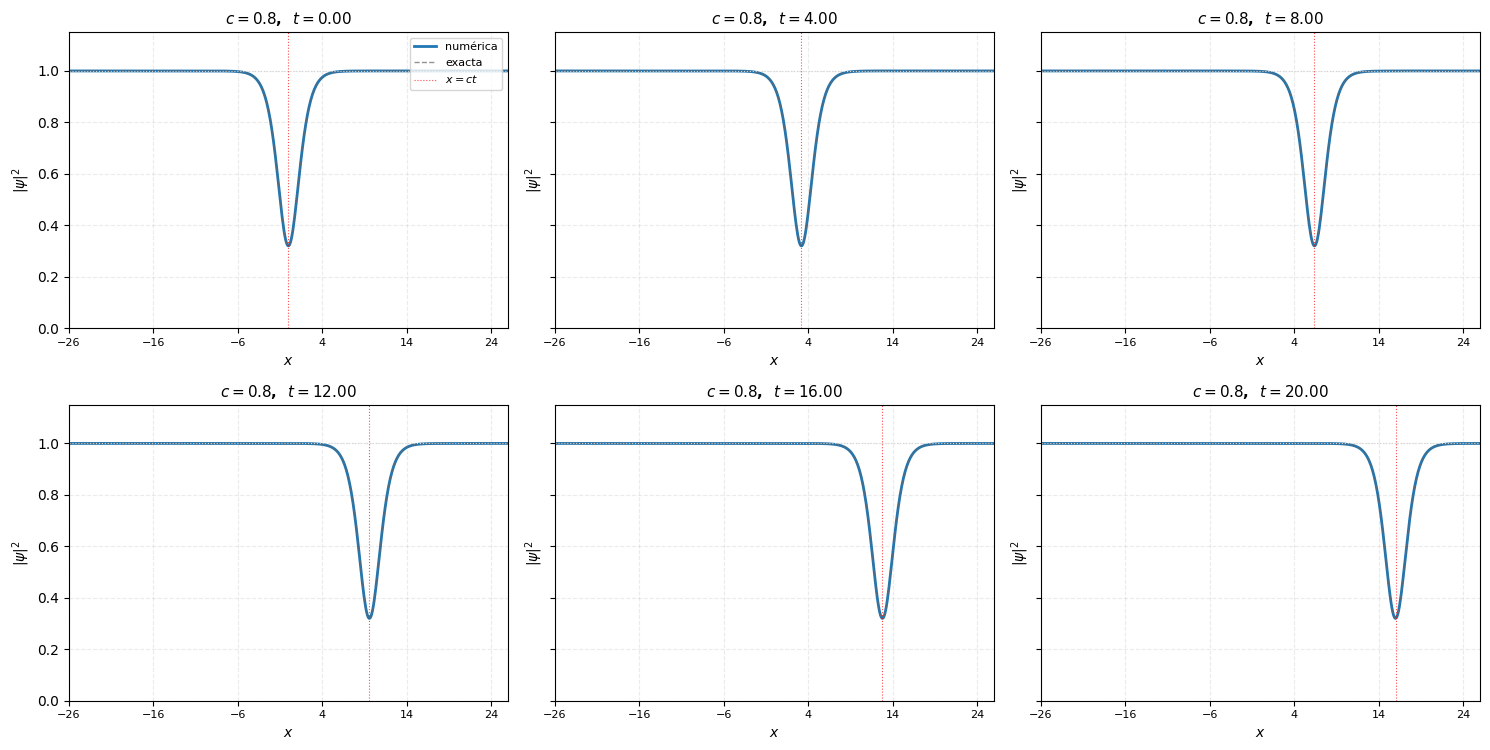

In [ ]:
# -- Verificar solucion exacta (residuo de la EDO de onda viajera) --
X, h_grid, eta_grid = construir_grilla_13()
c_check = 0.8
psi_check = solucion_exacta13(X, c=c_check, t=0)
res_check = residuo(psi_check, h_grid, c=c_check)
print(f"Residuo max |ic*psi' + psi'' + psi(1-|psi|^2)| = {np.abs(res_check[5:-5]).max():.2e}")
print("(debe ser ~1e-4 o menor; escala con h^2)")

# -- Simulacion sin perturbacion --
res_verif = simular_13(c=0.8, tipo_pert='ninguna', T=20.0, dt=0.005,
                       L=40, N=800, n_snapshots=6)
graficar_13(res_verif)


In [ ]:
# Diagnostico: el minimo de |psi|^2 debe seguir x = c*t
res_test = simular_13(c=0.8, tipo_pert='ninguna', T=15.0, dt=0.001,
                      L=60, N=1200, n_snapshots=6)

for k in range(len(res_test['t'])):
    psi_k = res_test['PSI'][k]
    idx   = np.argmin(np.abs(psi_k)**2)
    t_k   = res_test['t'][k]
    print(f"t={t_k:5.2f}: x_min={res_test['x'][idx]:6.2f}  (esperado: {0.8*t_k:.2f})")


t= 0.00: x_min= -0.05  (esperado: 0.00)
t= 3.00: x_min=  2.35  (esperado: 2.40)
t= 6.00: x_min=  4.75  (esperado: 4.80)
t= 9.00: x_min=  7.16  (esperado: 7.20)
t=12.00: x_min=  9.56  (esperado: 9.60)
t=15.00: x_min= 11.96  (esperado: 12.00)


## Experimento 2 — Indicador $k(t)$ para distintos $\sigma$ (Di Menza Fig. 4)

**Parámetros del paper:** $h=0.002$, $L=50$, $\delta t=0.2$, $T=2000$. Para Colab usamos parámetros reducidos (misma física, menor costo).

  Simulando sigma=1...
  Simulando sigma=2...
  Simulando sigma=5...


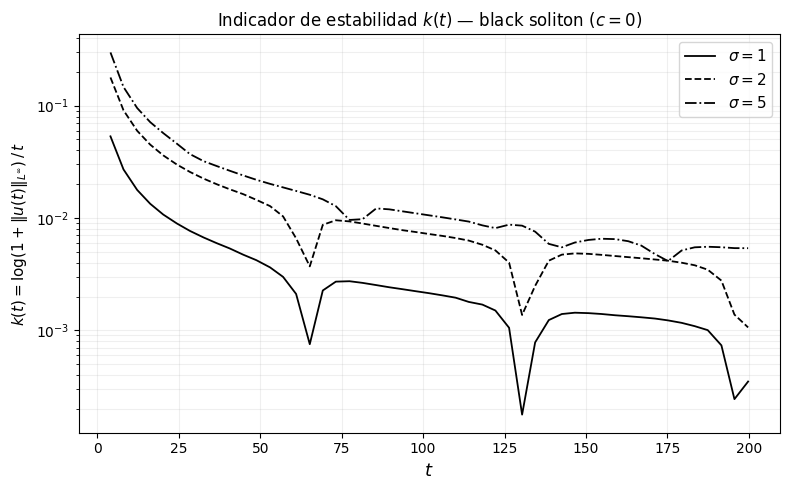

In [ ]:
resultados_kt = {}
for sigma in [1, 2, 5]:
    print(f"  Simulando sigma={sigma}...")
    res = simular_13(c=0.0, tipo_pert='gaussiana', epsilon=1.0, sigma=sigma,
                     T=200.0, dt=0.2, L=50, N=5000, n_snapshots=50)
    resultados_kt[f'$\\sigma={sigma}$'] = res

graficar_kt(resultados_kt,
           titulo=r'Indicador de estabilidad $k(t)$ — black soliton ($c=0$)')


## Experimento 3 — Perturbación tipo paper $\varepsilon(x)=q(1+i)e^{-0.01x^2}\cos x$

Reproduce la simulación no lineal de Di Menza (2007) eq. (6.3).

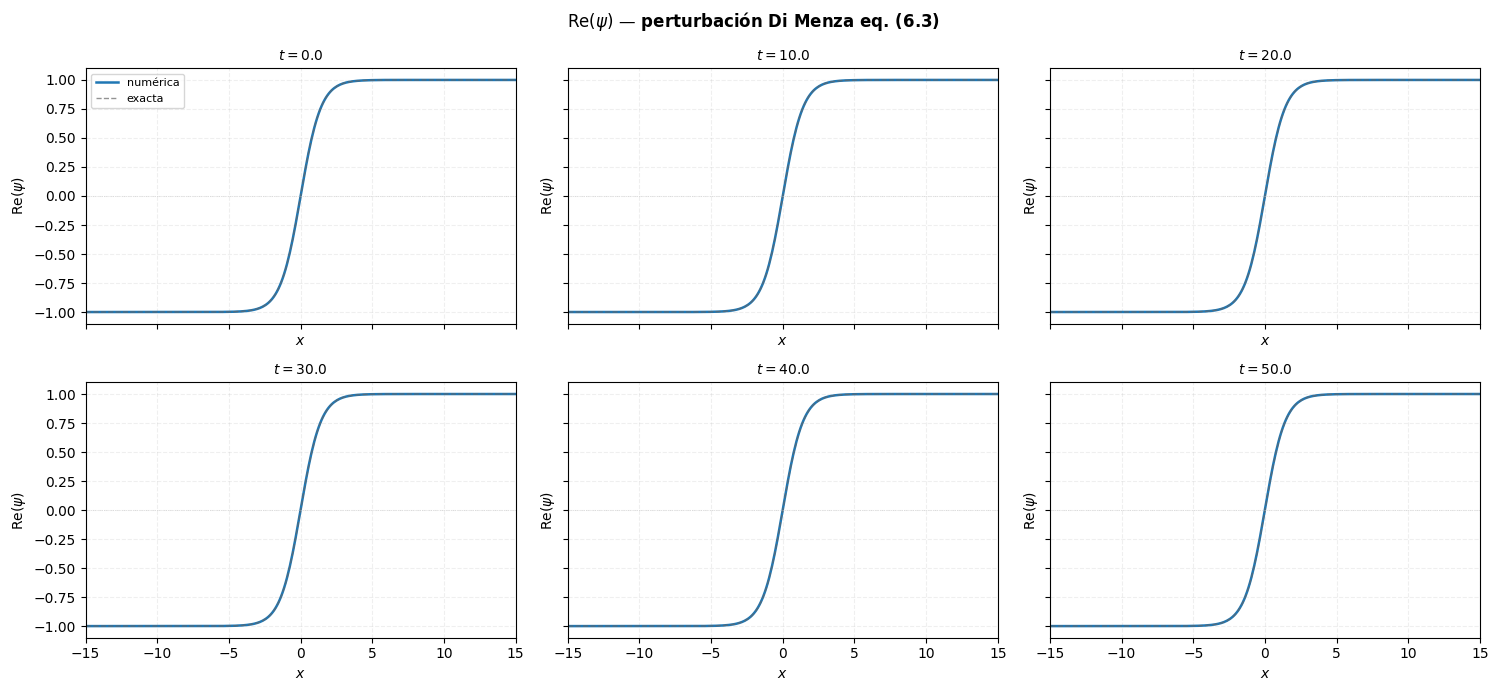

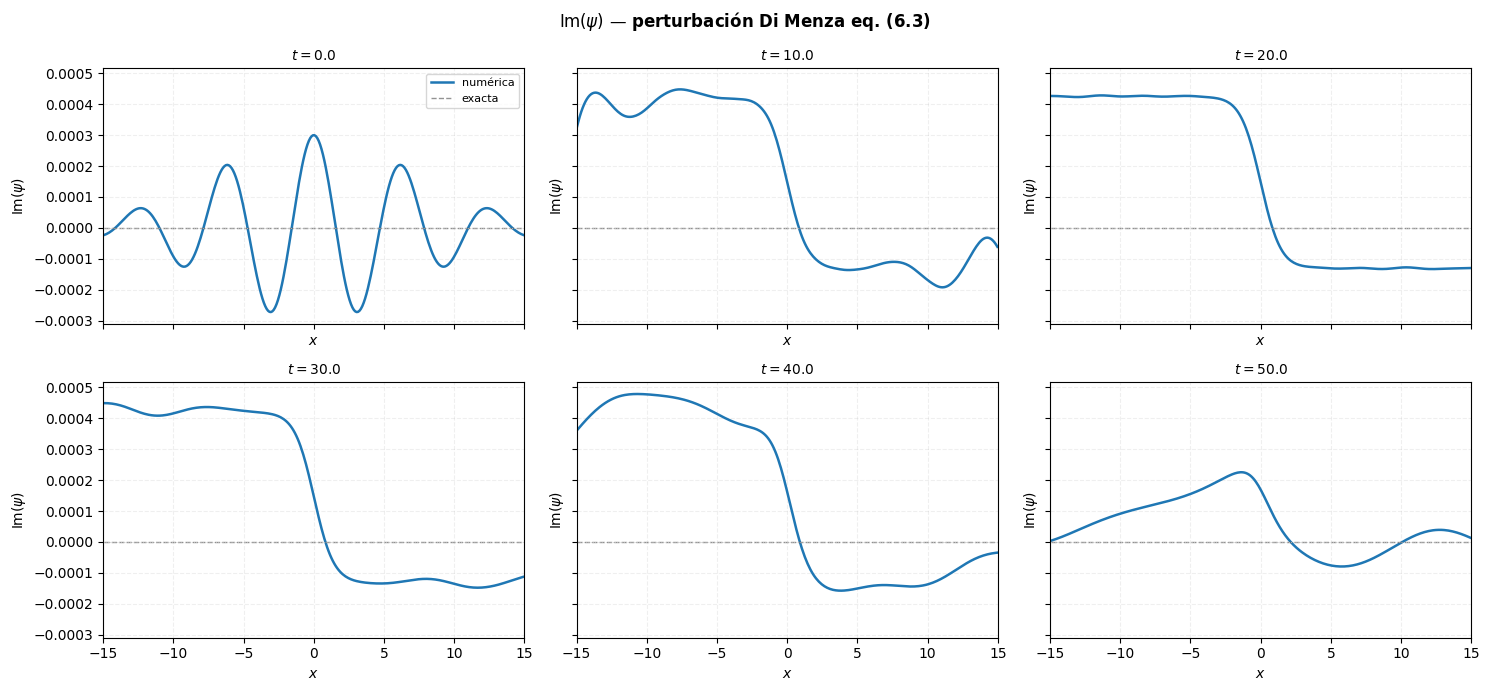

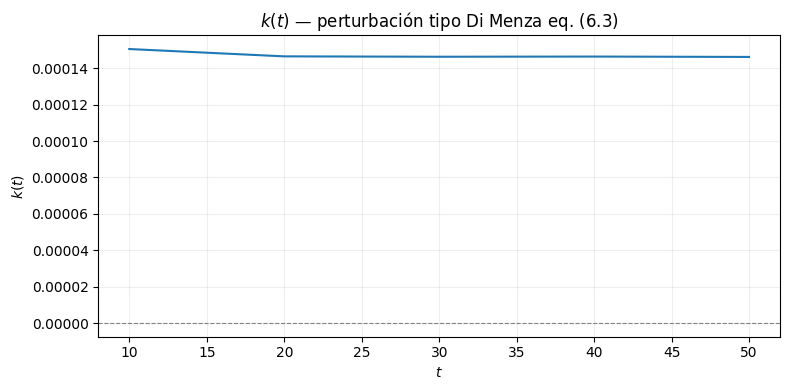

k(T) = 1.46e-04  (-> 0 indica estabilidad)


In [ ]:
res_paper = simular_13(c=0.0, tipo_pert='paper', q=3e-4,
                       T=50.0, dt=0.005, L=40, N=800, n_snapshots=6)

graficar_real_13(res_paper, x_rango=(-15, 15),
                 titulo=r'$\mathrm{Re}(\psi)$ — perturbación Di Menza eq. (6.3)')

graficar_imaginaria_13(res_paper, x_rango=(-15, 15),
                       titulo=r'$\mathrm{Im}(\psi)$ — perturbación Di Menza eq. (6.3)')

t_p, k_p = calcular_kt(res_paper)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_p[1:], k_p[1:], color=COLOR_NUM, linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('$t$'); ax.set_ylabel(r'$k(t)$')
ax.set_title(r'$k(t)$ — perturbación tipo Di Menza eq. (6.3)')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"k(T) = {k_p[-1]:.2e}  (-> 0 indica estabilidad)")


## Experimento 4 — Splitting del black soliton bajo perturbación grande

Con $\varepsilon$ más grande se observa el splitting en dos dark solitons viajeros.

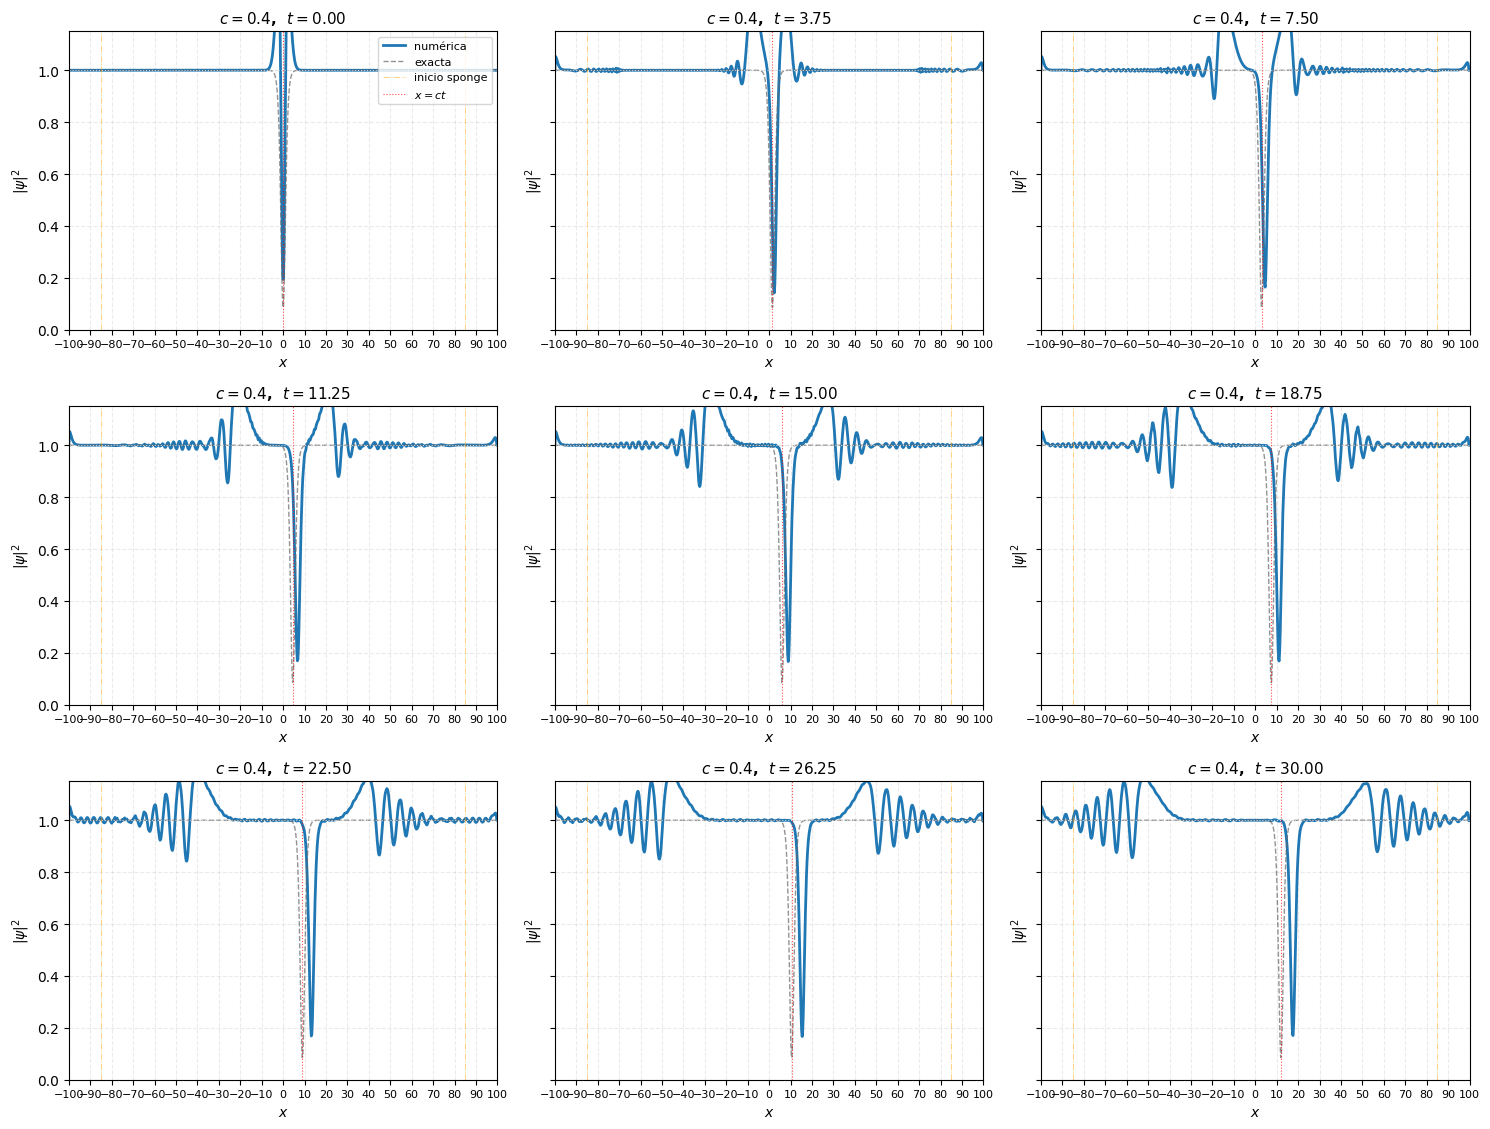

In [ ]:
res_split = simular_13(c=0.4, tipo_pert='gaussiana', epsilon=0.5,
                       sigma=3.0, T=30.0, dt=0.005,
                       L=100, N=800, n_snapshots=9)
graficar_13(res_split, x_rango=(-100, 100))


## Experimento 5 — Dark soliton viajero ($c\neq0$)

La condición de borde sigue la solución exacta en cada instante. Diagnóstico: el mínimo de $|\psi|^2$ debe seguir $x=ct$.

**Nota:** elegí $L$ suficientemente grande para que $c\,T$ no se acerque al borde del dominio — si el soliton llega a la zona de sponge, el mínimo medido se distorsiona (no es un error del esquema, es que salió de la ventana simulada).

Posicion del minimo de |psi|^2:
  t=0.0: x_min=-0.050  (esperado: 0.000)
  t=5.0: x_min=4.153  (esperado: 3.996)
  t=10.0: x_min=8.257  (esperado: 7.996)
  t=15.0: x_min=12.160  (esperado: 11.996)
  t=20.0: x_min=16.264  (esperado: 15.996)
  t=25.0: x_min=20.367  (esperado: 19.996)
  t=30.0: x_min=24.370  (esperado: 23.996)
  t=35.0: x_min=28.374  (esperado: 27.996)
  t=40.0: x_min=32.477  (esperado: 31.996)


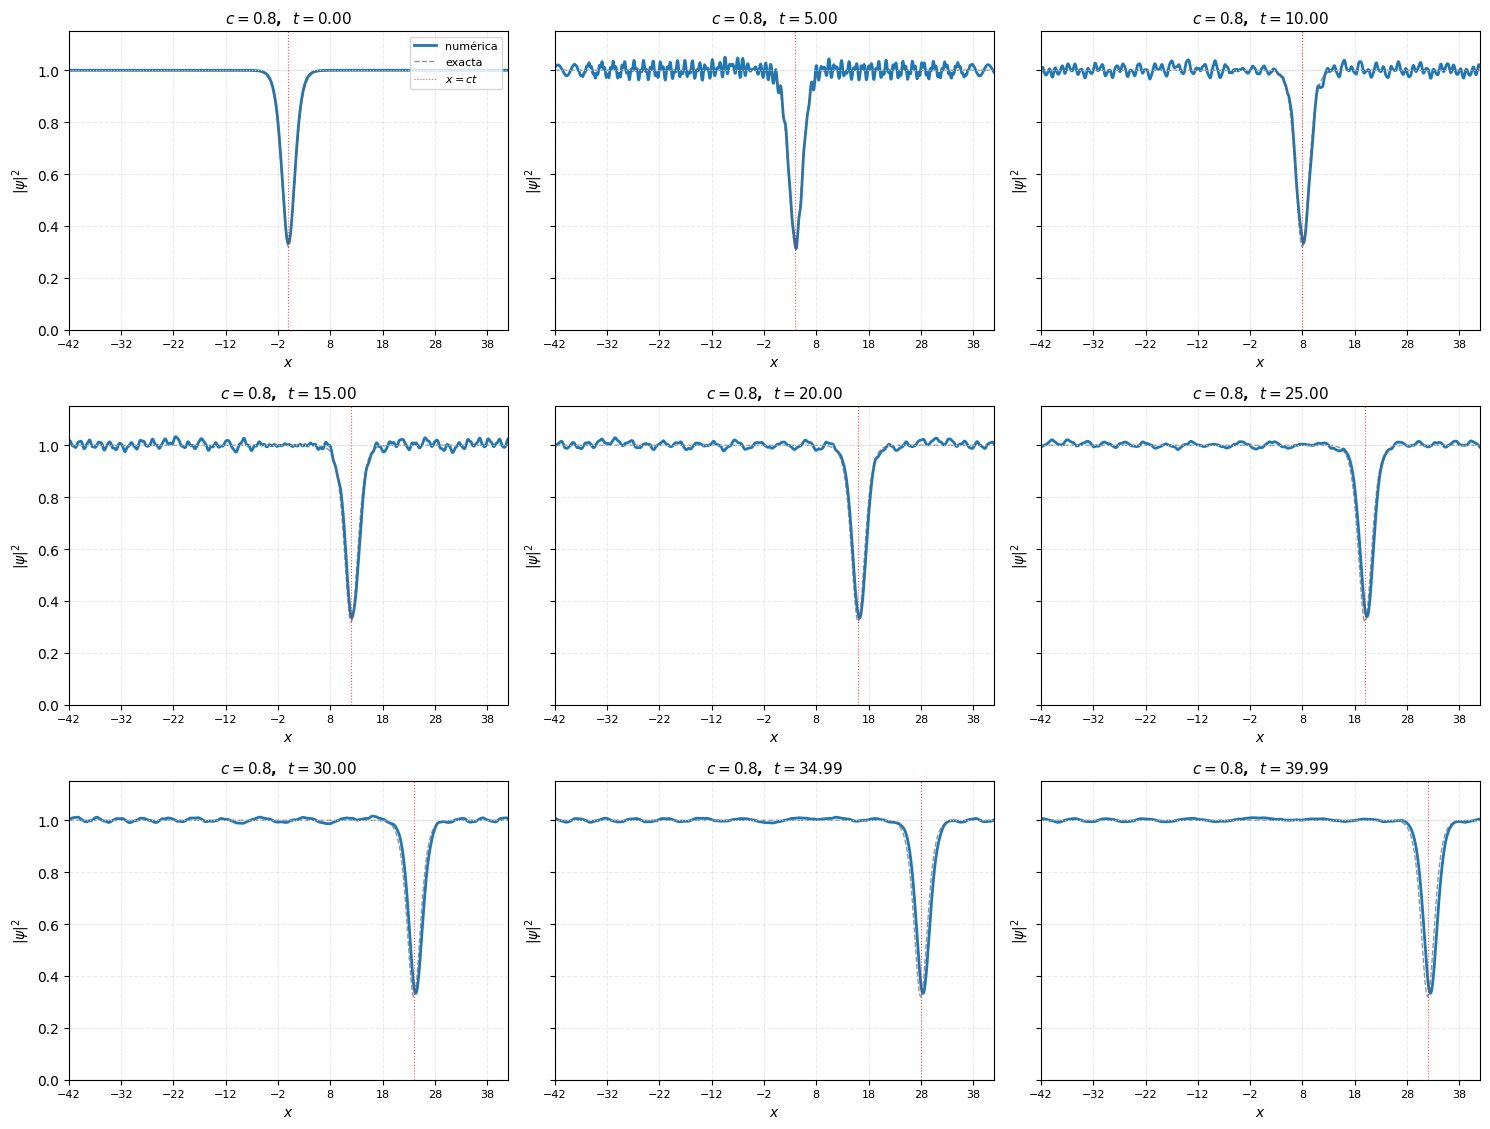

In [ ]:
c_val = 0.8
res_dark = simular_13(c=c_val, tipo_pert='gaussiana', epsilon=0.02, sigma=3.0,
                      T=40.0, dt=0.005, L=60, N=1200, n_snapshots=9)

print("Posicion del minimo de |psi|^2:")
for k in range(len(res_dark['t'])):
    psi_k = res_dark['PSI'][k]
    idx   = np.argmin(np.abs(psi_k)**2)
    t_k   = res_dark['t'][k]
    print(f"  t={t_k:.1f}: x_min={res_dark['x'][idx]:.3f}  (esperado: {c_val*t_k:.3f})")

graficar_13(res_dark)


---
# Solución 1.2 — Sistema acoplado (namespace `_12`)

$$i\partial_t\psi = \partial_{xx}\psi + \psi(1-|\psi|^2-\alpha|\phi|^2)$$
$$i\partial_t\phi = \partial_{xx}\phi + \phi(1-\alpha|\psi|^2-\beta|\phi|^2)$$

Todas las funciones de esta sección usan sufijo `_12` para no chocar con las de la Solución 1.3 de arriba.

## Parámetros y solución exacta

In [ ]:
def parametros_sol12(alpha, beta, c):
    den1, den2 = 2*(beta-alpha), beta-alpha**2
    b2   = den2/den1 - c**2/4
    A1sq = 1 - c**2*(beta-alpha)/(2*den2)
    B1sq = c**2*(beta-alpha)/(2*den2)
    A2sq = (alpha-1)*(2*den2 - c**2*(beta-alpha))/(den1*den2)
    lam  = alpha - 1 - den2/den1 + c**2/4
    if b2   <= 0: print(f"[aviso] b^2={b2:.3g} <= 0  -> fuera de la region de existencia.")
    if A2sq <= 0: print(f"[aviso] A2^2={A2sq:.3g} <= 0 -> phi=0 (degenerado, p.ej. alpha=1).")
    b  = np.sqrt(b2) if b2 > 0 else np.nan
    A1 = np.sqrt(max(A1sq, 0.0))
    B1 = -np.sqrt(max(B1sq, 0.0))            # signo corregido (-i)
    A2 = np.sqrt(A2sq) if A2sq > 0 else 0.0
    return A1, b, B1, A2, lam


def solucion_exacta12(x, par, c, t):
    A1, b, B1, A2, lam = par
    xi  = x - c*t
    psi = A1*np.tanh(b*xi) + 1j*B1
    phi = A2/np.cosh(b*xi) * np.exp(1j*((lam + c**2/4)*t - c*x/2))
    return psi, phi


## Grilla y esquemas temporales — Solución 1.2

Mismas dos correcciones que en la Sección 1.3: `r=1/(2h²)` y sponge post-paso sobre la desviación del fondo.

In [ ]:
def construir_grilla_12(L=40, N=800, w=6.0, eta0=3.0):
    x = np.linspace(-L, L, N); h = x[1]-x[0]
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    return x, h, eta


def _lap(f, h):
    d2 = np.zeros_like(f)
    d2[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2])/h**2
    return d2


def paso_CN_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg, n_iter=6):
    N = len(psi); r = 1.0/(2*h**2)
    pk, fk = psi.copy(), phi.copy()
    for _ in range(n_iter):
        pm, fm = (psi+pk)/2, (phi+fk)/2
        Vp = 1 - np.abs(pm)**2 - alpha*np.abs(fm)**2
        Vf = 1 - alpha*np.abs(pm)**2 - beta*np.abs(fm)**2
        for src, V, bi, bd, tag in [(psi, Vp, psi_bg[0], psi_bg[-1], 'p'),
                                    (phi, Vf, phi_bg[0], phi_bg[-1], 'f')]:
            rhs  = 1j/dt*src + r*(np.roll(src,1)-2*src+np.roll(src,-1)) + (V/2)*src
            diag = 1j/dt + 2*r - V/2
            ab = np.zeros((3,N), complex); ab[0,1:]=-r; ab[1,:]=diag; ab[2,:-1]=-r
            ab[1,0]=1; ab[0,1]=0; rhs[0]=bi; ab[1,-1]=1; ab[2,-2]=0; rhs[-1]=bd
            sol = solve_banded((1,1), ab, rhs)
            if tag=='p': pk = sol
            else:        fk = sol
    am = np.exp(-eta*dt)
    return psi_bg + (pk-psi_bg)*am, phi_bg + (fk-phi_bg)*am


def paso_RK4_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg):
    def F(p, f):
        Fp = -1j*(_lap(p,h) + p*(1-np.abs(p)**2-alpha*np.abs(f)**2))
        Ff = -1j*(_lap(f,h) + f*(1-alpha*np.abs(p)**2-beta*np.abs(f)**2))
        return Fp, Ff
    p1,f1 = F(psi,phi)
    p2,f2 = F(psi+0.5*dt*p1, phi+0.5*dt*f1)
    p3,f3 = F(psi+0.5*dt*p2, phi+0.5*dt*f2)
    p4,f4 = F(psi+dt*p3,     phi+dt*f3)
    psi = psi + dt/6*(p1+2*p2+2*p3+p4)
    phi = phi + dt/6*(f1+2*f2+2*f3+f4)
    psi[0],psi[-1] = psi_bg[0],psi_bg[-1]
    phi[0],phi[-1] = phi_bg[0],phi_bg[-1]
    am = np.exp(-eta*dt)
    return psi_bg + (psi-psi_bg)*am, phi_bg + (phi-phi_bg)*am


## Función de simulación — Solución 1.2 (`simular_12`)

In [ ]:
def simular_12(alpha=-1.0, beta=-2.0, c=1.0, tipo_pert='paper',
               q=3e-4, epsilon=0.05, sigma=3.0, q_phi=0.0,
               T=20.0, dt=0.005, L=40, N=800, n_snapshots=6):
    par = parametros_sol12(alpha, beta, c)
    A1, b, B1, A2, lam = par
    x, h, eta = construir_grilla_12(L=L, N=N)
    nt = int(T/dt)
    idx_guardar = np.linspace(0, nt-1, n_snapshots, dtype=int)

    psi_sol, phi_sol = solucion_exacta12(x, par, c, t=0)
    if   tipo_pert == 'paper':     psi = psi_sol + perturbacion_paper(x, q=q)
    elif tipo_pert == 'gaussiana': psi = perturbacion_gaussiana(psi_sol, x, epsilon, sigma)
    else:                          psi = psi_sol.copy()
    phi = phi_sol + q_phi*np.exp(-x**2/sigma**2)    # semilla opcional en phi

    PSI = np.zeros((n_snapshots, N), complex)
    PHI = np.zeros((n_snapshots, N), complex)
    tiempos = np.zeros(n_snapshots); idx_snap = 0

    for n in range(nt):
        t = n*dt
        if idx_snap < n_snapshots and n == idx_guardar[idx_snap]:
            PSI[idx_snap], PHI[idx_snap], tiempos[idx_snap] = psi, phi, t
            idx_snap += 1
            if idx_snap == n_snapshots: break
        psi_bg, phi_bg = solucion_exacta12(x, par, c, t=t)
        if abs(c) < 1e-10:
            psi, phi = paso_CN_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg)
        else:
            psi, phi = paso_RK4_12(psi, phi, h, dt, eta, alpha, beta, psi_bg, phi_bg)

    return dict(x=x, h=h, t=tiempos, PSI=PSI, PHI=PHI, psi_sol=psi_sol, phi_sol=phi_sol,
                alpha=alpha, beta=beta, c=c, A1=A1, b=b, B1=B1, A2=A2, lam=lam, L=L)


## Gráfico — Solución 1.2 (`graficar_12`)

Apila $\psi$ (fila superior) y $\phi$ (fila inferior), una columna por snapshot, con color fijo `COLOR_NUM` para la curva numérica en todos los paneles.

In [ ]:
def graficar_12(res, densidad=True, x_rango=None, x_sponge=None):
    """
    psi (fila superior) y phi (fila inferior), una columna por snapshot.
    densidad=True -> |.|^2 ; False -> |.|
    """
    x, t, c, L = res['x'], res['t'], res['c'], res['L']
    par = (res['A1'], res['b'], res['B1'], res['A2'], res['lam'])
    n = len(t)
    f = (lambda z: np.abs(z)**2) if densidad else (lambda z: np.abs(z))
    ylab = {'psi': r'$|\psi|^2$' if densidad else r'$|\psi|$',
            'phi': r'$|\phi|^2$' if densidad else r'$|\phi|$'}

    if x_rango is None:
        margen = min(max(15, abs(c)*t[-1] + 10), L)
        x_rango = (-margen, margen)
    else:
        x_min, x_max = x_rango
        if x_min < -L or x_max > L:
            print(f"Aviso: x_rango {x_rango} excede [-{L},{L}]. Se recorta.")
            x_rango = (max(x_min,-L), min(x_max,L))
    mask = (x >= x_rango[0]) & (x <= x_rango[1])
    if x_sponge is None: x_sponge = 0.85*L

    ymax_psi = 1.15
    pico = res['A2']**2 if densidad else res['A2']
    ymax_phi = 1.15*pico if pico > 0 else 1.0

    fig, axes = plt.subplots(2, n, figsize=(5*n, 7.6), sharex=True, squeeze=False)
    for k in range(n):
        t_k = t[k]
        psi_ex, phi_ex = solucion_exacta12(x, par, c, t_k)
        filas = [('psi', res['PSI'][k], psi_ex, 1.0,  ymax_psi),
                 ('phi', res['PHI'][k], phi_ex, None, ymax_phi)]
        for fila, (comp, campo_num, campo_ex, fondo, ymax) in enumerate(filas):
            ax = axes[fila][k]
            ax.plot(x[mask], f(campo_num[mask]), color=COLOR_NUM, lw=2, label='numérica')
            ax.plot(x[mask], f(campo_ex[mask]), color=COLOR_EX, lw=1, ls='--', alpha=0.7, label='exacta')
            if fondo is not None: ax.axhline(fondo, color='lightgray', lw=0.8, ls=':')
            for xs, lab in [(x_sponge, None), (-x_sponge, 'inicio sponge' if k==0 else None)]:
                if x_rango[0] <= xs <= x_rango[1]:
                    ax.axvline(xs, color='orange', lw=0.7, ls='-.', alpha=0.5, label=lab)
            if abs(c) > 0.01:
                ax.axvline(c*t_k, color='red', lw=0.8, ls=':', alpha=0.7,
                           label=r'$x=ct$' if k==0 else None)
            if fila == 0: ax.set_title(rf'$c={c}$,  $t={t_k:.2f}$', fontsize=11, fontweight='bold')
            ax.set_ylabel(ylab[comp]); ax.set_xlim(x_rango); ax.set_ylim(0, ymax)
            ax.grid(True, alpha=0.25, ls='--')
            if k == 0: ax.legend(fontsize=8, loc='upper right')
        axes[1][k].set_xlabel('$x$')

    fig.suptitle(rf"Solución 1.2 — ψ (arriba) y φ (abajo)   "
                 rf"($\alpha={res['alpha']:.0f},\ \beta={res['beta']:.0f},\ c={res['c']:.0f}$)", y=1.01)
    plt.tight_layout()
    plt.show()


## Sponge — visualización

Verifica visualmente que $\eta(x)$ sea 0 en el interior y monótono creciente hacia el borde.

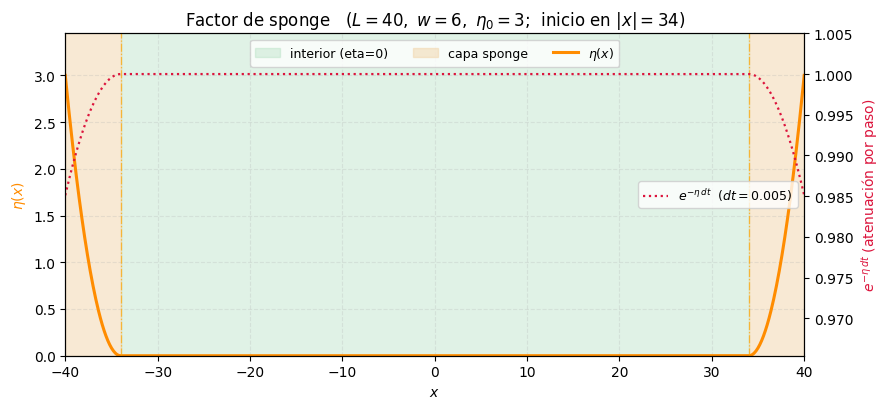

In [ ]:
def graficar_sponge(L=40, N=800, w=6.0, eta0=3.0, dt=None):
    """Visualiza el factor de sponge eta(x) usado en la simulacion."""
    x   = np.linspace(-L, L, N)
    eta = construir_sponge(x, L, w=w, eta0=eta0)
    x_on = L - w

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.axvspan(-x_on, x_on, color="#a8dbb8", alpha=0.35, label="interior (eta=0)")
    ax.axvspan(-L, -x_on,  color="#f0d0a0", alpha=0.45, label="capa sponge")
    ax.axvspan( x_on,  L,  color="#f0d0a0", alpha=0.45)

    ax.plot(x, eta, color="darkorange", lw=2.2, label=r"$\eta(x)$")
    for xs in (x_on, -x_on):
        ax.axvline(xs, color="orange", lw=0.9, ls="-.", alpha=0.7)

    ax.set_xlabel("$x$"); ax.set_ylabel(r"$\eta(x)$", color="darkorange")
    ax.set_xlim(-L, L); ax.set_ylim(0, eta0*1.15)
    ax.set_title(rf"Factor de sponge   ($L={L},\ w={w},\ \eta_0={eta0}$;  "
                 rf"inicio en $|x|={x_on:.0f}$)")
    ax.grid(True, alpha=0.25, ls="--")

    if dt is not None:
        ax2 = ax.twinx()
        ax2.plot(x, np.exp(-eta*dt), color="crimson", lw=1.6, ls=":",
                 label=rf"$e^{{-\eta\,dt}}$  ($dt={dt}$)")
        ax2.set_ylabel(r"$e^{-\eta\,dt}$ (atenuación por paso)", color="crimson")
        ax2.set_ylim(np.exp(-eta0*dt)*0.98, 1.005)
        ax2.legend(loc="center right", fontsize=9)

    ax.legend(loc="upper center", fontsize=9, ncol=3)
    plt.tight_layout()
    plt.show()

graficar_sponge(L=40, w=6, eta0=3, dt=0.005)


## Experimentos — Solución 1.2 (sistema acoplado)

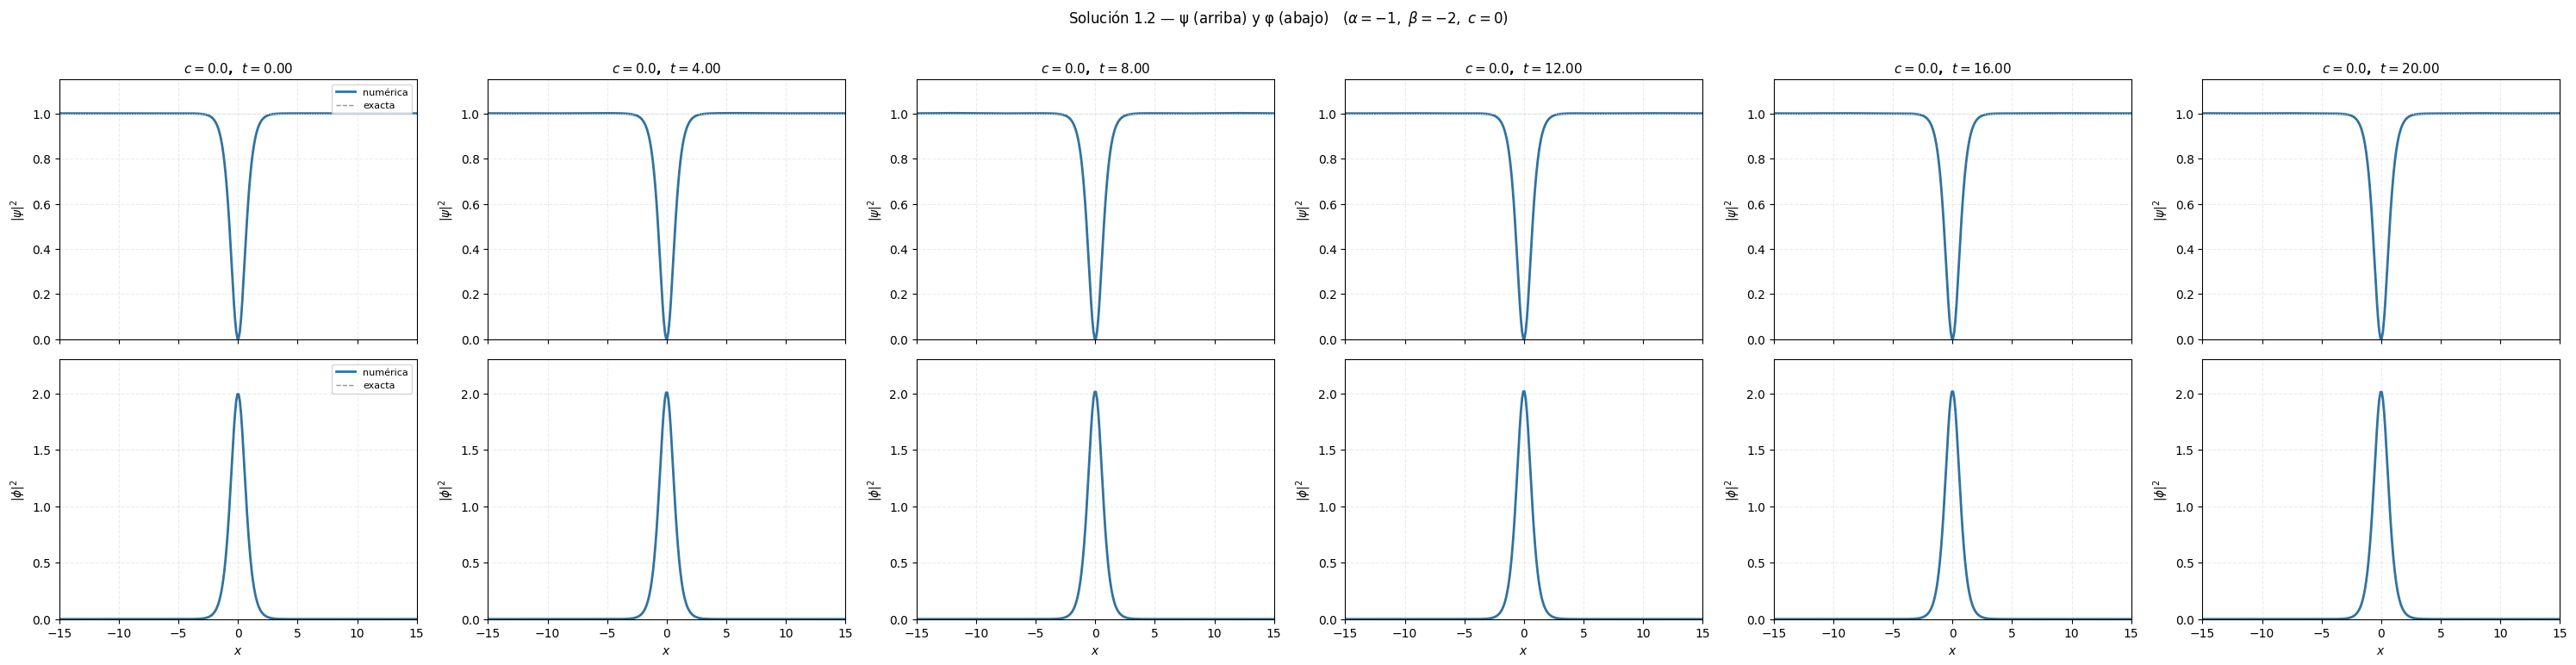

In [ ]:
# Verificacion: c=0, phi brillante estacionario, region de existencia 1
res_verif12 = simular_12(alpha=-1, beta=-2, c=0.0, tipo_pert='ninguna',
                         T=20.0, dt=0.005, L=40, N=800, n_snapshots=6)
graficar_12(res_verif12, densidad=True)


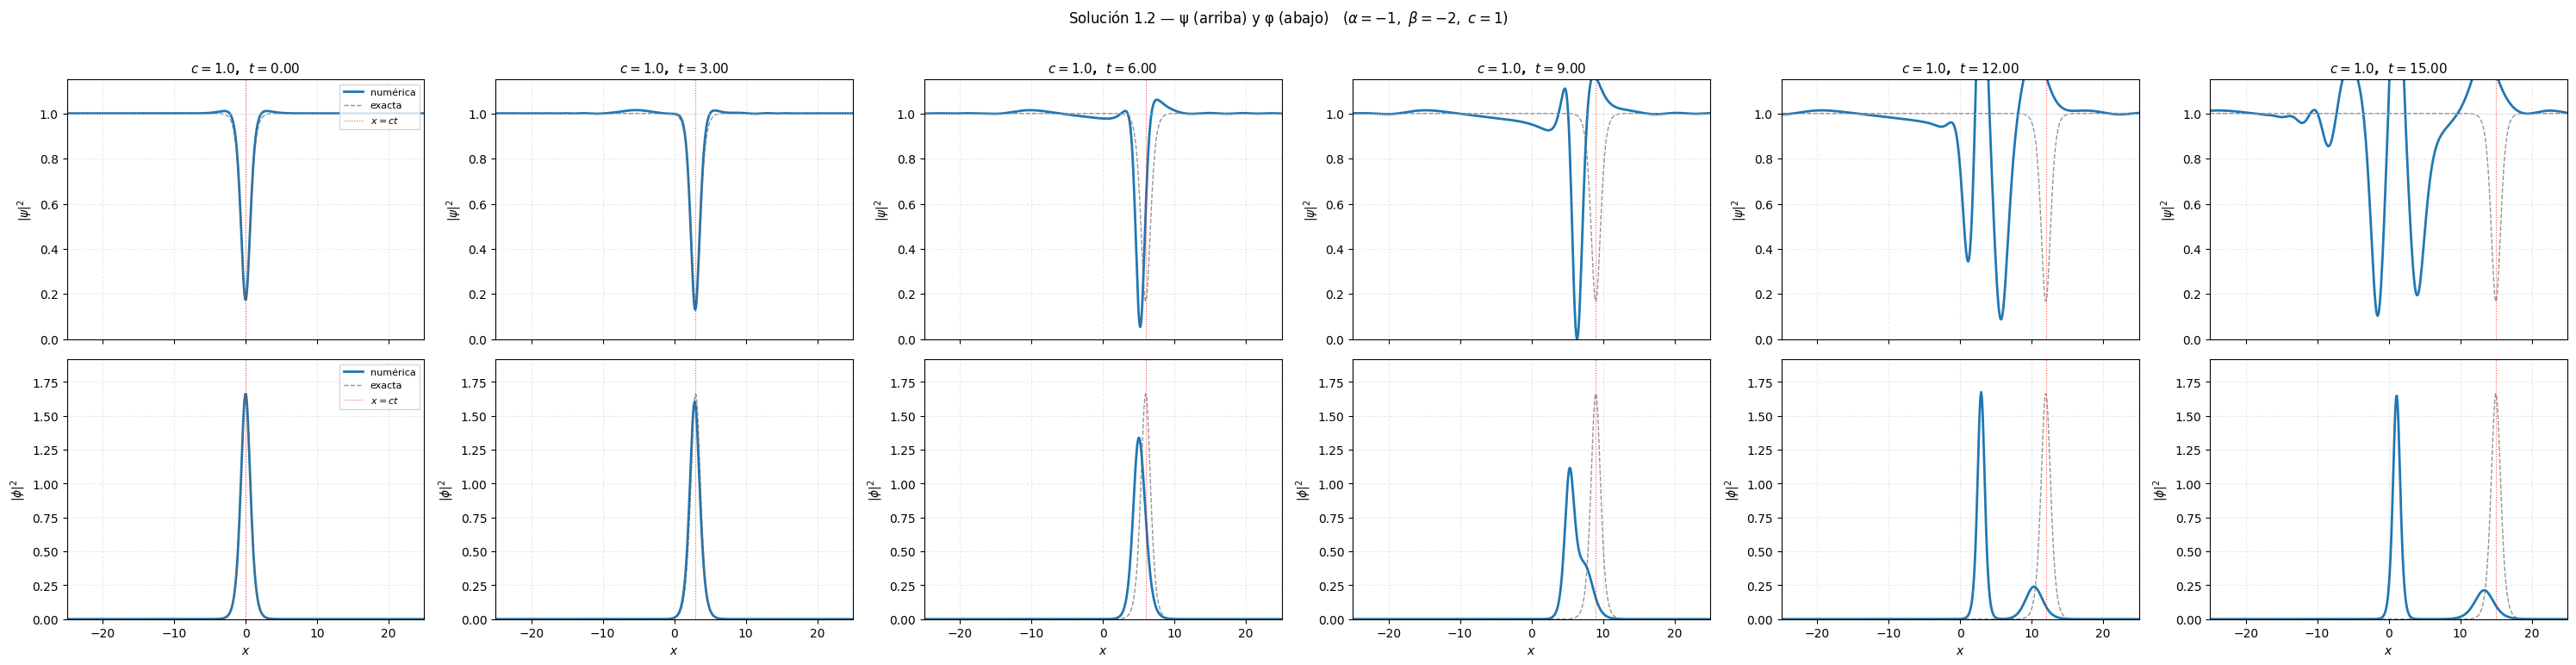

In [ ]:
# Caso viajero (c != 0, RK4)
res_12 = simular_12(alpha=-1, beta=-2, c=1.0, tipo_pert='gaussiana', epsilon=0.02,
                    T=15.0, dt=0.001, L=60, N=1200, n_snapshots=6)
graficar_12(res_12, densidad=True)


[aviso] A2^2=0 <= 0 -> phi=0 (degenerado, p.ej. alpha=1).


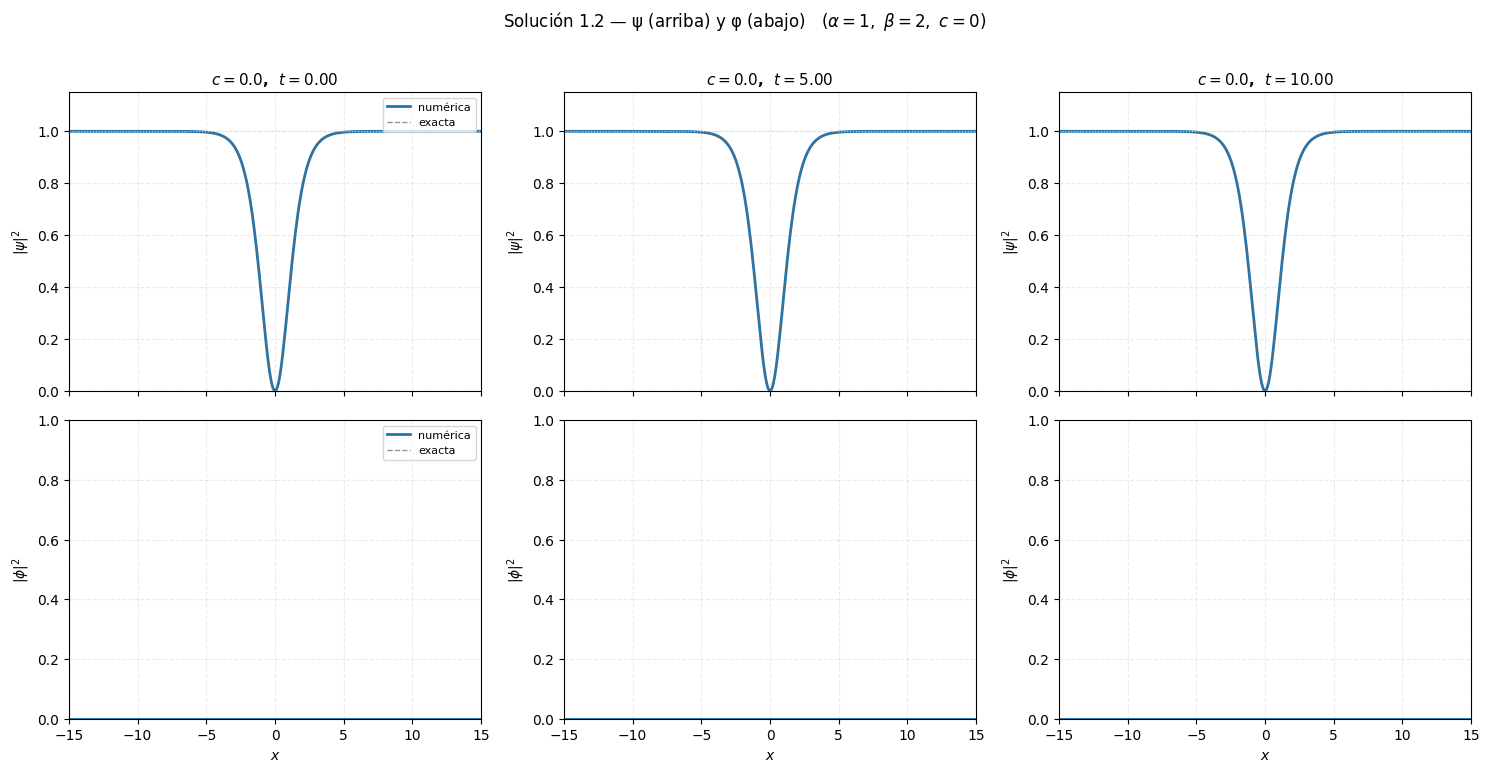

In [ ]:
# Caso degenerado (alpha=1 -> A2=0, phi=0): debe imprimir el aviso
res_degen = simular_12(alpha=1, beta=2, c=0.0, tipo_pert='ninguna',
                       T=10.0, dt=0.005, L=40, N=800, n_snapshots=3)
graficar_12(res_degen, densidad=True)
